# Notebook 04: Recommendation System

A content-based paper recommender using title embeddings.

## Features:
1. **Search by title** — find papers similar to a known paper
2. **Free-text query** — search with natural language
3. **Author-based** — find papers by a specific author
4. **Hybrid** — combine title similarity + co-authorship signals

---

In [1]:
import sys, os
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path(os.getcwd()).parent if 'notebooks' in os.getcwd() else Path(os.getcwd())
sys.path.insert(0, str(PROJECT_ROOT))

from src.parser import load_from_parquet
df = load_from_parquet(PROJECT_ROOT / "data" / "processed" / "dblp_subset.parquet")
print(f"Loaded {len(df):,} records")

Loaded 8,462,457 records


## 5.1 Prepare Data for Recommendation

We use a subset for the recommender.

In [2]:
# Use papers with valid titles
df_rec = df.dropna(subset=['title']).copy()
df_rec = df_rec[df_rec['title'].str.len() > 10].reset_index(drop=True)

# For demo, use a reasonable subset (adjust based on your hardware)
RECOMMENDER_SIZE = min(100_000, len(df_rec))
df_rec = df_rec.sample(n=RECOMMENDER_SIZE, random_state=42).reset_index(drop=True)

titles = df_rec['title'].tolist()
print(f"Recommender corpus: {len(df_rec):,} papers")

Recommender corpus: 100,000 papers


In [3]:
from src.embeddings import load_or_compute_embeddings

CACHE_DIR = PROJECT_ROOT / "data" / "processed"

# Compute or load embeddings
embeddings = load_or_compute_embeddings(
    titles,
    cache_path=CACHE_DIR / "embeddings_recommender.npy",
    method="transformer",
    model_name="all-MiniLM-L6-v2",
    batch_size=256,
)

print(f"Embeddings: {embeddings.shape}")

Loading model: all-MiniLM-L6-v2


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding 100,000 titles...


Batches:   0%|          | 0/391 [00:00<?, ?it/s]

Generated embeddings: shape (100000, 384)
Cached embeddings to d:\Rekrutacja_nokia\data\processed\embeddings_recommender.npy
Embeddings: (100000, 384)


## 5.2 Initialize Recommender

In [4]:
from src.recommender import ContentRecommender

recommender = ContentRecommender(
    df=df_rec,
    embeddings=embeddings,
    model_name="all-MiniLM-L6-v2",
)

Recommender initialized with 100,000 papers, embedding dim=384


## 5.3 Search by Paper Title

Find papers similar to a known paper in the dataset.

In [5]:
# Pick a random paper and find similar ones
sample_title = df_rec.iloc[0]['title']
print(f"Query paper: \"{sample_title}\"\n")

results = recommender.recommend_by_title(sample_title, top_k=10)
print(recommender.format_recommendations(results, sample_title))

Query paper: "A study about browsers in the Web and the Desktop."

Recommendations for: "A study about browsers in the Web and the Desktop."

1. Browsix: Bridging the Gap Between Unix and the Browser.
   Authors: Bobby Powers, John Vilk, Emery D. Berger
   Year: 2016 | Venue: CoRR
   Score: 0.6445

2. A Browser for Software Reuse.
   Authors: Panos Constantopoulos, Elena Pataki
   Year: 1992 | Venue: CAiSE
   Score: 0.6310

3. A reference architecture for web browsers: part II, a pattern for web browser content renderer.
   Authors: Paulina Silva, Raúl Monge, Eduardo B. Fernández
   Year: 2016 | Venue: EuroPLoP
   Score: 0.6114

4. A Browser Scanner: Collecting Intranet Information.
   Authors: Rio Hosoi, Takamichi Saito, Takayuki Ishikawa (+2 more)
   Year: 2016 | Venue: NBiS
   Score: 0.6083

5. Web applications: a test bed for advanced topics.
   Authors: Michael Olan
   Year: 2009 | Venue: J. Comput. Sci. Coll.
   Score: 0.5767

6. Information foraging models of browsers for very l

In [6]:
# Try with a specific topic
results = recommender.recommend_by_title("deep learning", top_k=10)
print(recommender.format_recommendations(results, "deep learning"))

Recommendations for: "deep learning"

1. Deep Learning Applications in Pre-Clinical Imaging for accelerated Drug Discovery Studies.
   Authors: Elena Vincenzi
   Year: 2024 | Venue: nan
   Score: 0.7003

2. An Interactive Visualization-Based Approach for High Throughput Screening Information Management in Drug Discovery.
   Authors: Tammy Pui Shan Chan, Preeti Malik, Rahul Singh
   Year: 2006 | Venue: EMBC
   Score: 0.6599

3. A Deep Learning Approach to the Prediction of Drug Side-Effects on Molecular Graphs.
   Authors: Pietro Bongini, Elisa Messori, Niccolò Pancino (+1 more)
   Year: 2023 | Venue: IEEE ACM Trans. Comput. Biol. Bioinform.
   Score: 0.6537

4. Accelerating De Novo Drug Design against Novel Proteins Using Deep Learning.
   Authors: Sowmya Ramaswamy Krishnan, Navneet Bung, Gopalakrishnan Bulusu (+1 more)
   Year: 2021 | Venue: J. Chem. Inf. Model.
   Score: 0.6473

5. DeepD_DrugC: Deep and distributed workflow to predict drug- candidates.
   Authors: Karima Sid, Soumia 

## 5.4 Free-Text Query

Search using natural language — no need to match an exact title.

In [7]:
queries = [
    "graph neural networks for social network analysis",
    "reinforcement learning in robotics",
    "privacy-preserving machine learning with differential privacy",
    "natural language processing with large language models",
    "quantum computing algorithms for optimization",
]

for query in queries:
    print("\n" + "="*70)
    results = recommender.recommend_by_query(query, top_k=5)
    print(recommender.format_recommendations(results, query))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Recommendations for: "graph neural networks for social network analysis"

1. On Graph Learning with Neural Networks.
   Authors: Zahra Jandaghi, Liming Cai
   Year: 2020 | Venue: LOD (2)
   Score: 0.7435

2. Graph Structure of Neural Networks.
   Authors: Jiaxuan You, Jure Leskovec, Kaiming He (+1 more)
   Year: 2020 | Venue: CoRR
   Score: 0.6931

3. Representative Graph Neural Network.
   Authors: Changqian Yu, Yifan Liu 0001, Changxin Gao (+2 more)
   Year: 2020 | Venue: ECCV (7)
   Score: 0.6726

4. Graph Summarization with Graph Neural Networks.
   Authors: Maximilian Blasi, Manuel Freudenreich, Johannes Horvath (+2 more)
   Year: 2022 | Venue: CoRR
   Score: 0.6509

5. Channel-Attentive Graph Neural Networks.
   Authors: Tugrul Hasan Karabulut, Inci M. Baytas
   Year: 2025 | Venue: CoRR
   Score: 0.6500



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Recommendations for: "natural language processing with large language models"

1. A Natural Language Processing Model.
   Authors: J.-H. Jayez, P. Levasseur, M. Liscouet
   Year: 1980 | Venue: GI Jahrestagung
   Score: 0.7073

2. Large Language Models Meet NLP: A Survey.
   Authors: Libo Qin 0001, Qiguang Chen, Xiachong Feng (+6 more)
   Year: 2024 | Venue: CoRR
   Score: 0.6919

3. Statistical Natural Language Processing.
   Authors: Florentina T. Hristea
   Year: 2011 | Venue: International Encyclopedia of Statistical Science
   Score: 0.6847

4. Paraphrasing with Large Language Models.
   Authors: Sam Witteveen, Martin Andrews
   Year: 2019 | Venue: NGT@EMNLP-IJCNLP
   Score: 0.6597

5. Strategies for Training Large Vocabulary Neural Language Models.
   Authors: Wenlin Chen, David Grangier, Michael Auli
   Year: 2015 | Venue: CoRR
   Score: 0.6406



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Recommendations for: "quantum computing algorithms for optimization"

1. Solving Highly Constrained Search Problems with Quantum Computers
   Authors: Tad Hogg
   Year: 2011 | Venue: CoRR
   Score: 0.7865

2. A low failure rate quantum algorithm for searching maximum or minimum.
   Authors: Yanhu Chen, Shijie Wei, Xiong Gao (+4 more)
   Year: 2020 | Venue: Quantum Inf. Process.
   Score: 0.7567

3. Quantum Algorithms for Classical Probability Distributions.
   Authors: Aleksandrs Belovs
   Year: 2019 | Venue: ESA
   Score: 0.7550

4. Performance Analysis of Quantum-Inspired Evolutionary Algorithm.
   Authors: Tomohisa Takata, Teijiro Isokawa, Nobuyuki Matsui
   Year: 2011 | Venue: J. Adv. Comput. Intell. Intell. Informatics
   Score: 0.7549

5. Quantum differential evolutionary algorithm with quantum-adaptive mutation strategy and population state evaluation framework for high-dimensional problems.
   Authors: Wu Deng 0001, Jiarui Wang, Aibin Guo (+1 more)
   Year: 2024 | Venue: Inf. S

## 5.5 Author-Based Search

In [8]:
# Find papers by a specific author
# Let's find a well-known author in our dataset
df_exploded = df_rec.explode('authors')
top_authors = df_exploded['authors'].value_counts().head(10)
print("Top authors in recommender corpus:")
print(top_authors.to_string())

# Search by top author
author = top_authors.index[0]
print(f"\n\n📚 Papers by {author}:")
author_results = recommender.recommend_by_author(author, top_k=10)
author_results

Top authors in recommender corpus:
authors
H. Vincent Poor         37
Philip S. Yu            35
Dusit Niyato            33
Mohamed-Slim Alouini    31
Dacheng Tao             29
Licheng Jiao            28
Lei Zhang               28
Wei Wang                27
Yu Zhang                25
Jing Li                 25


📚 Papers by H. Vincent Poor:


,title,authors,year,venue
0,What is the Value of Heuristic Model Selection...,"[Chenhao Xu 0003, Youyang Qu, Ming Ding 0001, ...",2026,IEEE Netw.
1,Interference Free Multi-User Coded ISAC With P...,"[Sümeyra Hassan, Negin Kazemipourleilabadi, Ib...",2026,IEEE J. Sel. Areas Commun.
2,Characterization of the Arithmetic Complexity ...,"[Holger Boche, Andrea Grigorescu, Rafael F. Sc...",2025,CoRR
3,On the Convexification of Non-Linear Optimizat...,"[Holger Boche, Volker Pohl, H. Vincent Poor]",2025,CDC
4,Near-Field Multipath MIMO Channel Model for Im...,"[Mohamadreza Delbari, George C. Alexandropoulo...",2024,GLOBECOM (Workshops)
5,Efficient RL with Impaired Observability: Lear...,"[Minshuo Chen, Yu Bai 0017, H. Vincent Poor, M...",2023,CoRR
6,"Modeling Statistical Delay, Error-Rate, and Jo...","[Xi Zhang 0005, Jingqing Wang 0001, H. Vincent...",2023,ISIT
7,Self-adaptive Bat Algorithm With Genetic Opera...,"[Jing Bi 0001, Haitao Yuan 0001, Jiahui Zhai, ...",2022,IEEE CAA J. Autom. Sinica
8,Protecting Physical Layer Secret Key Generatio...,"[Miroslav Mitev, Arsenia Chorti, Elena Veronic...",2021,Entropy
9,On Optimal Quantization in Sequential Detection.,"[Michael Fauß, Manuel S. Stein, H. Vincent Poor]",2021,CoRR


## 5.6 Hybrid Recommendations

Combining title similarity with co-authorship for better results.

In [ ]:
# Hybrid recommendation
sample_title = df_rec.iloc[0]['title']
print(f"Query: \"{sample_title}\"\n")

print("--- Content-Only Recommendations ---")
content_results = recommender.recommend_by_title(sample_title, top_k=5)
print(recommender.format_recommendations(content_results, sample_title))

print("\n\n--- Hybrid Recommendations (content + co-authorship) ---")
hybrid_results = recommender.hybrid_recommend(sample_title, author_weight=0.3, top_k=5)
print(recommender.format_recommendations(hybrid_results, sample_title))

## 5.7 Quality Assessment

Let's qualitatively evaluate recommendation quality.

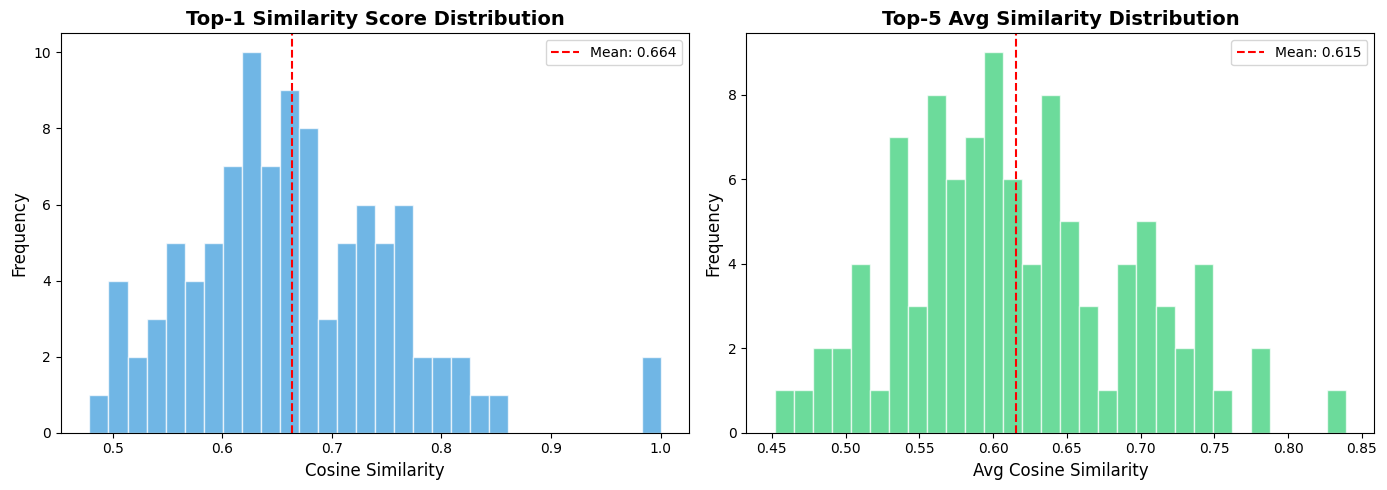


Recommendation Quality Metrics:
Average top-1 similarity: 0.6638
Average top-5 similarity: 0.6154
These scores indicate the average semantic relevance of recommendations.


In [9]:
import matplotlib.pyplot as plt

# Similarity score distribution for random queries
np.random.seed(42)
sample_indices = np.random.choice(len(df_rec), size=100, replace=False)

top1_scores = []
top5_avg_scores = []

for idx in sample_indices:
    query_emb = embeddings[idx]
    from src.embeddings import find_similar
    indices, scores = find_similar(query_emb, embeddings, top_k=6)
    # Exclude self
    other_scores = scores[indices != idx][:5]
    if len(other_scores) > 0:
        top1_scores.append(other_scores[0])
        top5_avg_scores.append(other_scores.mean())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(top1_scores, bins=30, color='#3498db', alpha=0.7, edgecolor='white')
ax1.set_xlabel('Cosine Similarity', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Top-1 Similarity Score Distribution', fontsize=14, fontweight='bold')
ax1.axvline(np.mean(top1_scores), color='red', linestyle='--', label=f'Mean: {np.mean(top1_scores):.3f}')
ax1.legend()

ax2.hist(top5_avg_scores, bins=30, color='#2ecc71', alpha=0.7, edgecolor='white')
ax2.set_xlabel('Avg Cosine Similarity', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Top-5 Avg Similarity Distribution', fontsize=14, fontweight='bold')
ax2.axvline(np.mean(top5_avg_scores), color='red', linestyle='--', label=f'Mean: {np.mean(top5_avg_scores):.3f}')
ax2.legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data' / 'processed' / 'recommendation_quality.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRecommendation Quality Metrics:")
print(f"Average top-1 similarity: {np.mean(top1_scores):.4f}")
print(f"Average top-5 similarity: {np.mean(top5_avg_scores):.4f}")
print(f"These scores indicate the average semantic relevance of recommendations.")